# H4 — Effet de la CSP (adresse riche / pauvre) sur l'évaluation des CV

**Ce qu'on teste :** Le marqueur socio-économique de l'adresse (quartier riche vs pauvre)
influence-t-il la probabilité d'acceptation d'un CV ?
Et cette influence est-elle modulée par l'ethnicité du candidat ?

**Lecture :**
- **Variante 1** — Effet principal de la CSP en mode *single* : P(accepter) riche vs pauvre par modèle.
- **Variante 2** — Interaction ethnicité × CSP en mode *single* : pour chaque modèle, les deux
  courbes (riche/pauvre) se croisent-elles selon l'ethnicité ?
- **Variante 3** — Mode *comparatif* : la CSP du contexte modifie-t-elle la préférence ethnique
  (P(Français choisi)) ?

> *Données partielles : fichiers en cours de collecte, résultats provisoires.*


In [1]:
import sys
sys.path.insert(0, '..')
from utils.analysis import *

set_style()

df     = charger_behavioral()
single = df[df.eval_mode == 'single']
comp   = df[df.eval_mode == 'comparative'].dropna(subset=['chose_majorite'])
MODELES = modeles_tries(df)

print(f"Single : {len(single)} lignes | Comparatif : {len(comp)} lignes")
print("Modèles :", MODELES)


Single : 1172 lignes | Comparatif : 1304 lignes
Modèles : ['Mistral-Nemo-Novita', 'Qwen3.6-27B-FP8', 'Gemma-4-31B-it', 'Qwen3.7-max-Novita']


## Exploration — P(accepter) par CSP, modèle et ethnicité


In [2]:
# P(accepter) par CSP × modèle × ethnicité
tbl = (
    single
    .groupby(['model', 'address_condition', 'condition'])['accepte']
    .agg(p_accept='mean', n='count')
    .round(3)
    .reset_index()
)
tbl['address_condition'] = tbl['address_condition'].map(ETIQ_CSP)
tbl['condition']         = tbl['condition'].map(ETIQ_ETH)
tbl.columns = ['Modèle', 'CSP', 'Ethnicité', 'P(accepter)', 'N']
display(tbl)


,Modèle,CSP,Ethnicité,P(accepter),N
0,Gemma-4-31B-it,Pauvre,Africain,0.400,50
1,Gemma-4-31B-it,Pauvre,Français,0.420,50
2,Gemma-4-31B-it,Pauvre,Maghrébin,0.420,50
3,Gemma-4-31B-it,Riche,Africain,0.440,50
4,Gemma-4-31B-it,Riche,Français,0.460,50
5,Gemma-4-31B-it,Riche,Maghrébin,0.440,50
6,Mistral-Nemo-Novita,Pauvre,Africain,0.878,41
7,Mistral-Nemo-Novita,Pauvre,Français,0.816,49
8,Mistral-Nemo-Novita,Pauvre,Maghrébin,0.848,46
9,Mistral-Nemo-Novita,Riche,Africain,0.766,47


In [3]:
# Résumé : P(accepter) par CSP × modèle (toutes ethnicités)
tbl2 = (
    single
    .groupby(['model', 'address_condition'])['accepte']
    .mean()
    .unstack('address_condition')
    .rename(columns=ETIQ_CSP)
)
tbl2['Δ (Riche−Pauvre)'] = (tbl2['Riche'] - tbl2['Pauvre']).round(3)
tbl2[['Riche', 'Pauvre']] = tbl2[['Riche', 'Pauvre']].round(3)
tbl2.index.name = 'Modèle'
display(tbl2)


address_condition,Pauvre,Riche,Δ (Riche−Pauvre)
Modèle,,,
Gemma-4-31B-it,0.413,0.447,0.033
Mistral-Nemo-Novita,0.846,0.784,-0.061
Qwen3.6-27B-FP8,0.557,0.507,-0.050
Qwen3.7-max-Novita,0.393,0.380,-0.013


### Variante 1 — Effet principal (barres groupées + Δ)


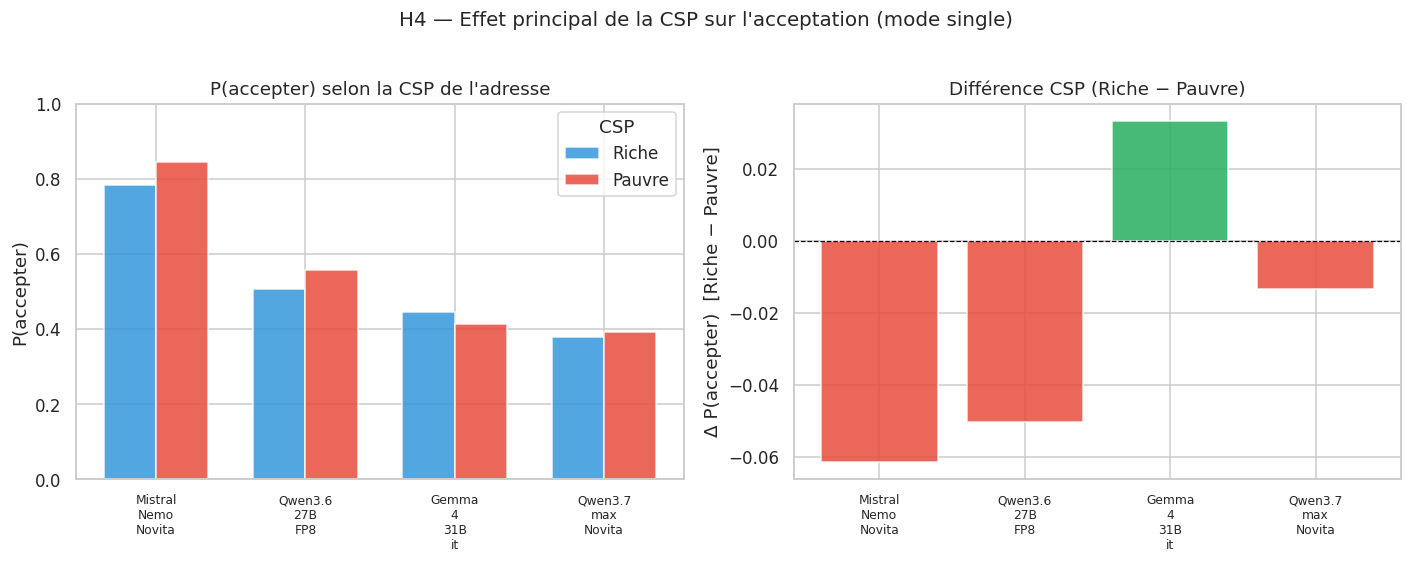

In [4]:
from scipy.stats import chi2_contingency

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Barres groupées ---
ax = axes[0]
x    = np.arange(len(MODELES))
w    = 0.35
coul = {'rich': '#3498DB', 'poor': '#E74C3C'}

for i, csp in enumerate(['rich', 'poor']):
    vals = [single[(single.model == m) & (single.address_condition == csp)]['accepte'].mean()
            for m in MODELES]
    bars = ax.bar(x + (i - 0.5) * w, vals, w,
                  label=ETIQ_CSP[csp], color=coul[csp], alpha=0.85, edgecolor='white')

# Étoiles chi² (acceptation × CSP)
for j, m in enumerate(MODELES):
    sub = single[single.model == m]
    ct  = pd.crosstab(sub['address_condition'], sub['accepte'].dropna().astype(int))
    if ct.shape == (2, 2):
        _, p, _, _ = chi2_contingency(ct)
        if p < 0.05:
            ymax = max(
                sub[sub.address_condition == 'rich']['accepte'].mean(),
                sub[sub.address_condition == 'poor']['accepte'].mean()
            )
            ax.text(x[j], ymax + 0.03, '*', ha='center', fontsize=14, color='black')

ax.set_xticks(x)
ax.set_xticklabels([m.replace('-', '\n') for m in MODELES], fontsize=8)
ax.set_ylabel('P(accepter)')
ax.set_title("P(accepter) selon la CSP de l'adresse")
ax.set_ylim(0, 1)
ax.legend(title='CSP')

# --- Delta riche - pauvre ---
ax2 = axes[1]
deltas = [
    single[(single.model == m) & (single.address_condition == 'rich')]['accepte'].mean()
    - single[(single.model == m) & (single.address_condition == 'poor')]['accepte'].mean()
    for m in MODELES
]
colors = ['#27AE60' if d >= 0 else '#E74C3C' for d in deltas]
ax2.bar(x, deltas, color=colors, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels([m.replace('-', '\n') for m in MODELES], fontsize=8)
ax2.set_ylabel('Δ P(accepter)  [Riche − Pauvre]')
ax2.set_title('Différence CSP (Riche − Pauvre)')

fig.suptitle("H4 — Effet principal de la CSP sur l'acceptation (mode single)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Variante 2 — Interaction ethnicité × CSP (petits multiples)


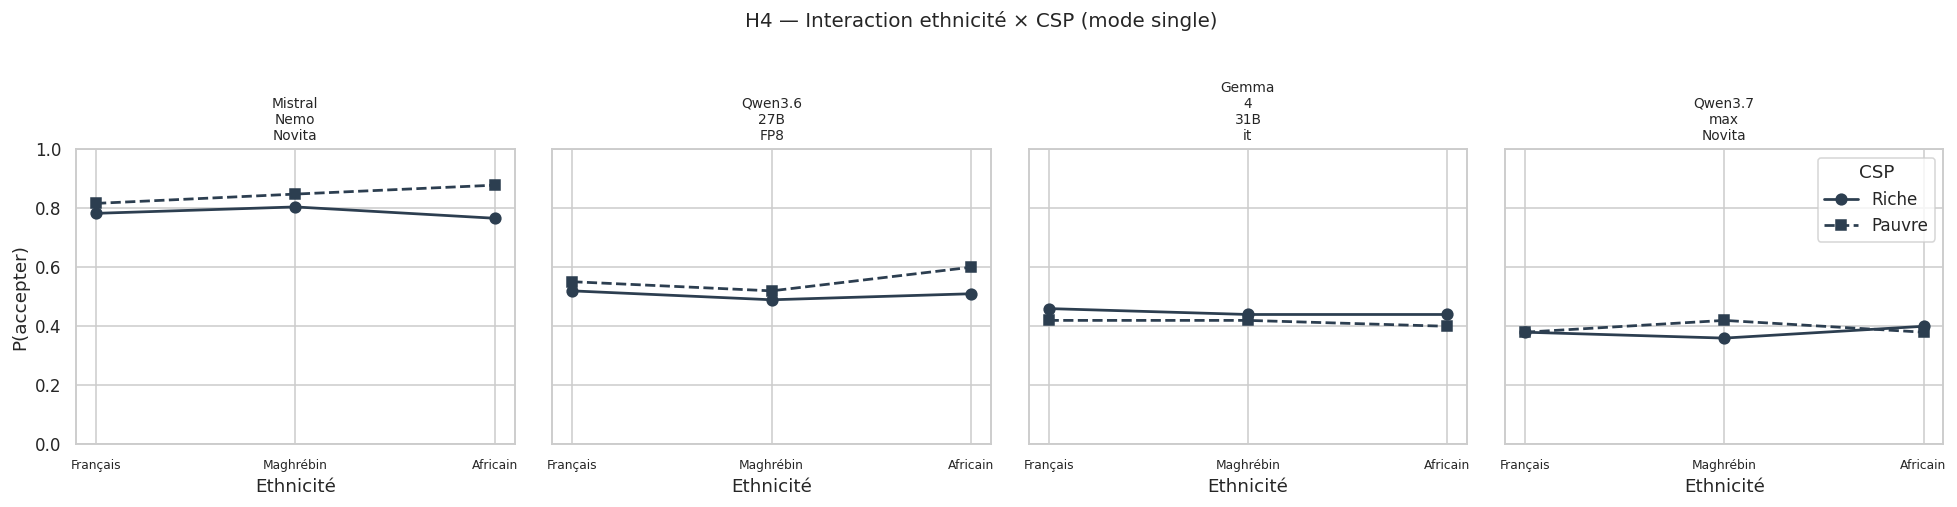

In [5]:
n_mod = len(MODELES)
fig, axes = plt.subplots(1, n_mod, figsize=(4.5 * n_mod, 4.5), sharey=True)
if n_mod == 1:
    axes = [axes]

ls_csp = {'rich': '-', 'poor': '--'}
mark   = {'rich': 'o', 'poor': 's'}

for ax, m in zip(axes, MODELES):
    sub = single[single.model == m]
    for csp in ['rich', 'poor']:
        ys = [
            sub[(sub.address_condition == csp) & (sub.condition == eth)]['accepte'].mean()
            for eth in ETHNIES
        ]
        ax.plot(
            [ETIQ_ETH[e] for e in ETHNIES], ys,
            linestyle=ls_csp[csp], marker=mark[csp], label=ETIQ_CSP[csp],
            color='#2C3E50', linewidth=1.8, markersize=7
        )
    ax.set_title(m.replace('-', '\n'), fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Ethnicité')
    ax.tick_params(axis='x', labelsize=8)

axes[0].set_ylabel('P(accepter)')
axes[-1].legend(title='CSP', loc='upper right')

fig.suptitle("H4 — Interaction ethnicité × CSP (mode single)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Variante 3 — Mode comparatif : la CSP modifie-t-elle la préférence ethnique ?


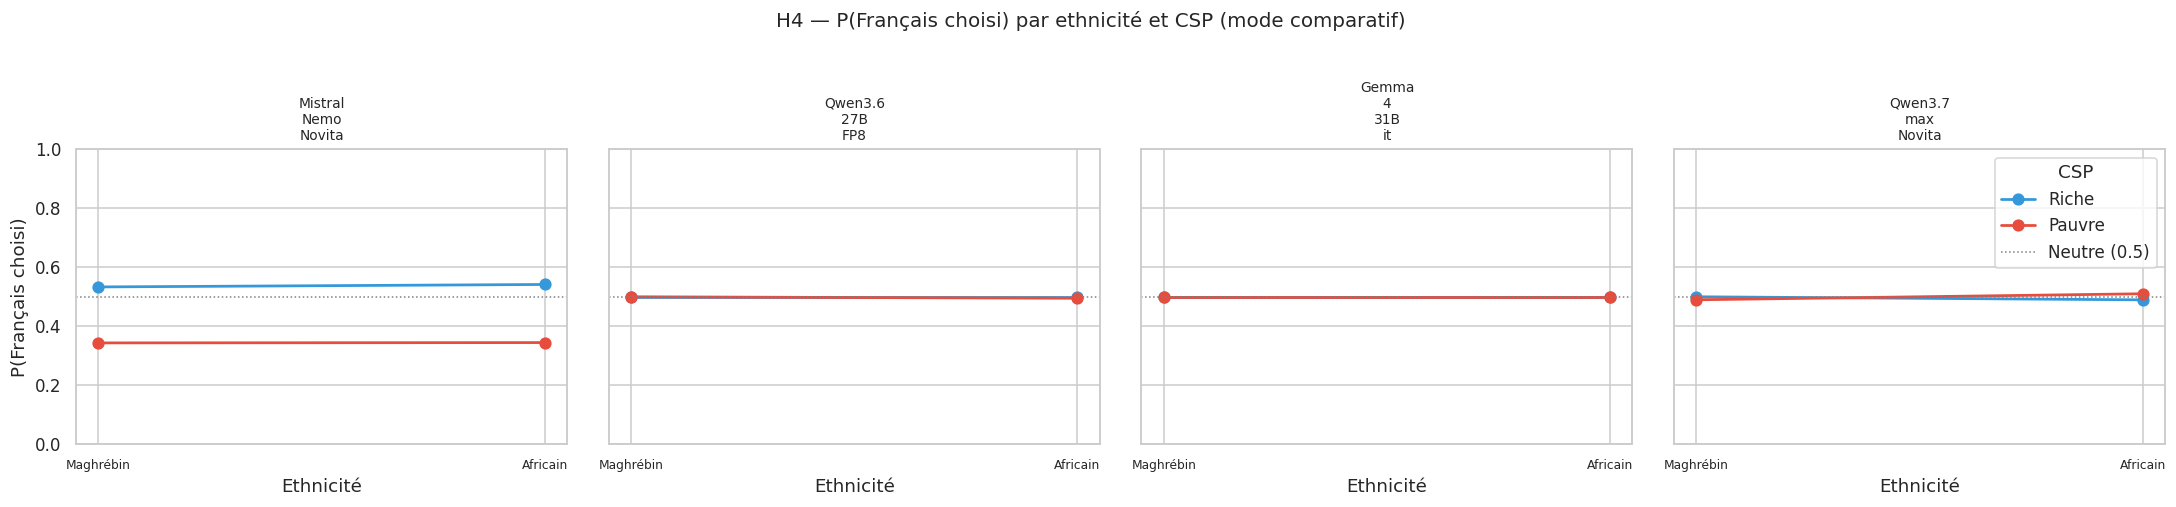

In [6]:
# Modèles ayant du comparatif
modeles_comp = [m for m in MODELES if m in comp['model'].unique()]

if not modeles_comp:
    print("Aucun modèle avec données comparatives disponibles.")
else:
    fig, axes = plt.subplots(1, len(modeles_comp), figsize=(5 * len(modeles_comp), 4.5), sharey=True)
    if len(modeles_comp) == 1:
        axes = [axes]

    coul_csp = {'rich': '#3498DB', 'poor': '#E74C3C'}

    for ax, m in zip(axes, modeles_comp):
        sub_m = comp[comp.model == m]
        for csp in ['rich', 'poor']:
            sub_csp = sub_m[sub_m.address_condition == csp]
            ys = []
            for eth in ETHNIES:
                s = sub_csp[sub_csp.condition == eth]['chose_majorite']
                ys.append(s.mean() if len(s) > 0 else np.nan)
            ax.plot(
                [ETIQ_ETH[e] for e in ETHNIES], ys,
                marker='o', label=ETIQ_CSP[csp],
                color=coul_csp[csp], linewidth=1.8, markersize=7
            )
        ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, label='Neutre (0.5)')
        ax.set_title(m.replace('-', '\n'), fontsize=9)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Ethnicité')
        ax.tick_params(axis='x', labelsize=8)

    axes[0].set_ylabel('P(Français choisi)')
    axes[-1].legend(title='CSP', loc='upper right')

    fig.suptitle(
        "H4 — P(Français choisi) par ethnicité et CSP (mode comparatif)",
        fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.show()


## Tests statistiques — χ² acceptation × CSP par modèle (mode single)


In [7]:
from scipy.stats import chi2_contingency

rows = []
for m in MODELES:
    sub = single[single.model == m].dropna(subset=['accepte'])
    sub = sub.copy()
    sub['accepte_int'] = sub['accepte'].astype(int)
    ct = pd.crosstab(sub['address_condition'], sub['accepte_int'])
    if ct.shape[1] < 2 or ct.shape[0] < 2:
        rows.append({'Modèle': m, 'χ²': np.nan, 'p-valeur': np.nan, 'sig': '—', 'N': len(sub)})
        continue
    chi2, p, dof, _ = chi2_contingency(ct)
    rows.append({
        'Modèle':   m,
        'χ²':       round(chi2, 3),
        'p-valeur': round(p, 4),
        'sig':      '✓ p<0.05' if p < 0.05 else 'n.s.',
        'N':        len(sub)
    })

tbl_stat = pd.DataFrame(rows).set_index('Modèle')
display(tbl_stat)


,χ²,p-valeur,sig,N
Modèle,,,,
Mistral-Nemo-Novita,1.334,0.2481,n.s.,275
Qwen3.6-27B-FP8,0.566,0.4519,n.s.,297
Gemma-4-31B-it,0.218,0.6409,n.s.,300
Qwen3.7-max-Novita,0.014,0.9056,n.s.,300
